Before proceeding with things, I want to know for sure the functionality of a time distributed layer. What does this layer do exactly, how to make sense out of this. The most commno encounter with this is in Numerical Machine Translation problems, where the Dense layer with softmax actiavation is wrapped in a TimeDistributed layer as the decoder outputs are a time series.

But what exactly happens here?

In [1]:
import tensorflow as tf
import numpy as np

2025-07-10 14:16:13.950989: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-10 14:16:13.987354: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-10 14:16:13.987377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-10 14:16:13.988279: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-10 14:16:13.994256: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Below is the keras example - It cosiders 32 video samples, each video is 10 frames, each frame is a 128,128,3 RGB image.

# For the time distributed layer - The input should be at least 3D, and the index = 1 should correspond to the time dimension

inputs = tf.keras.layers.Input(shape = (10,128,128,3), batch_size = 32)

conv2D_layer = tf.keras.layers.Conv2D(64, (3,3))

output = tf.keras.layers.TimeDistributed(conv2D_layer)(inputs)

2025-07-10 14:17:33.862131: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:86:00.0, compute capability: 7.0


In [3]:
example_model1 = tf.keras.models.Model(inputs = inputs, outputs = output)

In [4]:
example_model1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(32, 10, 128, 128, 3)]   0         
                                                                 
 time_distributed (TimeDist  (32, 10, 126, 126, 64)    1792      
 ributed)                                                        
                                                                 
Total params: 1792 (7.00 KB)
Trainable params: 1792 (7.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


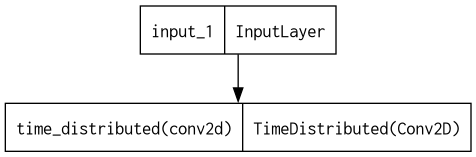

In [5]:
tf.keras.utils.plot_model(example_model1)

In [6]:
# there's 3 layers and then the bias
(3*3*64) * 3 + 64

1792

In [7]:
inputs.shape

TensorShape([32, 10, 128, 128, 3])

In [8]:
output.shape

TensorShape([32, 10, 126, 126, 64])

In [9]:
# can we do the same architecture but without the timedistributed layer?

In [10]:
inputs_example2 = tf.keras.layers.Input(shape = (10,128,128,3), batch_size = 32)

conv2D_layer = tf.keras.layers.Conv2D(64, (3,3))

output_output = conv2D_layer(inputs_example2)

In [11]:
output_output.shape

TensorShape([32, 10, 126, 126, 64])

In [12]:
example_model2 = tf.keras.models.Model(inputs = inputs_example2, outputs = output_output)

In [13]:
example_model2.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(32, 10, 128, 128, 3)]   0         
                                                                 
 conv2d_1 (Conv2D)           (32, 10, 126, 126, 64)    1792      
                                                                 
Total params: 1792 (7.00 KB)
Trainable params: 1792 (7.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


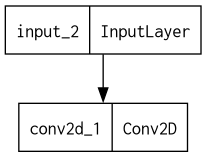

In [14]:
tf.keras.utils.plot_model(example_model2)

In [15]:
# Seems both these work -  should we train these models for a few epochs and see if we can get the same results?

In [16]:
# layer weights model 1

In [17]:
conv_layer_weights_ex1 = conv2D_layer.get_weights()

In [18]:
len(conv_layer_weights_ex1)

2

In [19]:
conv_layer_weights_ex1[0].shape, conv_layer_weights_ex1[1].shape

((3, 3, 3, 64), (64,))

In [20]:
# layer weights model 2

In [21]:
conv_layer_weights_ex2 = conv2D_layer.get_weights()

In [22]:
len(conv_layer_weights_ex2)

2

In [23]:
conv_layer_weights_ex2[0].shape, conv_layer_weights_ex2[1].shape

((3, 3, 3, 64), (64,))

In [24]:
# are these identical? since we are doing default initializers?
print(np.mean(conv_layer_weights_ex1[0] == conv_layer_weights_ex2[0]))
print(np.mean(conv_layer_weights_ex1[0] == conv_layer_weights_ex2[0]))

1.0
1.0


In [25]:
# generate some random values for input and output?

X_train = np.random.normal(loc=2, scale=3, size=(32, 10, 128, 128, 3))
y_train = np.random.random(size = (32, 10, 126, 126, 64))

In [26]:
X_train.shape

(32, 10, 128, 128, 3)

In [27]:
y_train.shape

(32, 10, 126, 126, 64)

In [28]:
# train the first model

# compile the model
example_model1.compile(optimizer = "adam", loss = 'mse', metrics = ['mae'])

In [29]:
example_model1.fit(X_train, y_train, epochs = 20)

Epoch 1/20


2025-07-10 14:17:45.417710: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-07-10 14:17:48.030264: I external/local_xla/xla/service/service.cc:168] XLA service 0x14c844e6e8b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-10 14:17:48.030292: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-07-10 14:17:48.035529: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1752175068.165816 3974487 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 [==============================] - 5s 5s/step - loss: 1.4326 - mae: 0.9554
Epoch 2/20
1/1 [==============================] - 0s 343ms/step - loss: 1.3643 - mae: 0.9310
Epoch 3/20
1/1 [==============================] - 0s 323ms/step - loss: 1.3005 - mae: 0.9079
Epoch 4/20
1/1 [==============================] - 0s 329ms/step - loss: 1.2411 - mae: 0.8860
Epoch 5/20
1/1 [==============================] - 0s 341ms/step - loss: 1.1859 - mae: 0.8654
Epoch 6/20
1/1 [==============================] - 0s 354ms/step - loss: 1.1348 - mae: 0.8460
Epoch 7/20
1/1 [==============================] - 0s 345ms/step - loss: 1.0873 - mae: 0.8278
Epoch 8/20
1/1 [==============================] - 0s 355ms/step - loss: 1.0433 - mae: 0.8105
Epoch 9/20
1/1 [==============================] - 0s 325ms/step - loss: 1.0025 - mae: 0.7943
Epoch 10/20
1/1 [==============================] - 0s 325ms/step - loss: 0.9647 - mae: 0.7790
Epoch 11/20
1/1 [==============================] - 0s 340ms/step - loss: 0.9295 - m

In [30]:
# weights of the trained first model for the conv layer
traied_conv_layer_weights_ex1 = example_model1.layers[1].get_weights()

In [31]:
traied_conv_layer_weights_ex1[0].shape, traied_conv_layer_weights_ex1[1].shape

((3, 3, 3, 64), (64,))

In [32]:
# train the secons model

# compile the model
example_model2.compile(optimizer = "adam", loss = 'mse', metrics = ['mae'])

In [33]:
example_model2.fit(X_train, y_train, epochs = 20)

Epoch 1/20
1/1 [==============================] - 2s 2s/step - loss: 1.5595 - mae: 1.0042
Epoch 2/20
1/1 [==============================] - 0s 325ms/step - loss: 1.4819 - mae: 0.9767
Epoch 3/20
1/1 [==============================] - 0s 318ms/step - loss: 1.4093 - mae: 0.9507
Epoch 4/20
1/1 [==============================] - 0s 354ms/step - loss: 1.3418 - mae: 0.9260
Epoch 5/20
1/1 [==============================] - 0s 343ms/step - loss: 1.2791 - mae: 0.9028
Epoch 6/20
1/1 [==============================] - 0s 340ms/step - loss: 1.2211 - mae: 0.8810
Epoch 7/20
1/1 [==============================] - 0s 347ms/step - loss: 1.1675 - mae: 0.8605
Epoch 8/20
1/1 [==============================] - 0s 317ms/step - loss: 1.1180 - mae: 0.8413
Epoch 9/20
1/1 [==============================] - 0s 326ms/step - loss: 1.0724 - mae: 0.8234
Epoch 10/20
1/1 [==============================] - 0s 330ms/step - loss: 1.0304 - mae: 0.8066
Epoch 11/20
1/1 [==============================] - 0s 326ms/step - loss:

In [34]:
# weights of the trained first model for the conv layer
traied_conv_layer_weights_ex2 = example_model2.layers[1].get_weights()

In [35]:
traied_conv_layer_weights_ex2[0].shape, traied_conv_layer_weights_ex2[1].shape

((3, 3, 3, 64), (64,))

In [36]:
# are these weights the same?
np.mean(traied_conv_layer_weights_ex2[0] == traied_conv_layer_weights_ex1[0])

0.0

In [37]:
# none of these are the same, I think this is to be expected. 

In [38]:
# traied_conv_layer_weights_ex2[0]

In [39]:
# but can we do a get weights and set weights from model 1 to 2?

In [40]:
example_model2.set_weights(example_model1.get_weights())

In [41]:
# so yes, this can be done

In [42]:
np.mean(example_model2.get_weights()[0] == traied_conv_layer_weights_ex1[0])

1.0

In [43]:
# What I want to know exactly is how does the back prop work in these two instances? Maybe need to learn this with a simpler example.

In [44]:
# Some examples I believe will help are as follows

In [45]:
# Machine learning mastery

In [46]:
# Imagine a situation where we give as input [0.0, 0.2 ,0.4, 0.6 ,0.8] at each time step and expect the sequence to be returned

In [47]:
length = 5
seq = np.array([i/float(length) for i in range(length)])
seq

array([0. , 0.2, 0.4, 0.6, 0.8])

In [48]:
# but we try to od this as a piece-wise problem 

# X Y
# 0.0 0.0
# 0.2 0.2
# 0.4 0.4
# 0.6 0.6
# 0.8 0.8

# And we are going to solve this as a seq-2-seq problem

In [49]:
X = seq.reshape(5,1,1)
Y = seq.reshape(5,1)

In [50]:
X.shape, Y.shape

((5, 1, 1), (5, 1))

In [51]:
# Define LSTM configuration

n_neurons = length
n_batch = length
n_epochs = 1000
input = tf.keras.layers.Input(shape = (1,1))
lstm_layer = tf.keras.layers.LSTM(n_neurons)
lstm_out = lstm_layer(input)
dense_layer = tf.keras.layers.Dense(1)
dense_out = dense_layer(lstm_out)

one_to_one_model = tf.keras.models.Model(inputs = input, outputs = dense_out)
one_to_one_model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 1, 1)]            0         
                                                                 
 lstm (LSTM)                 (None, 5)                 140       
                                                                 
 dense (Dense)               (None, 1)                 6         
                                                                 
Total params: 146 (584.00 Byte)
Trainable params: 146 (584.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [52]:
# compile model
one_to_one_model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

In [53]:
one_to_one_model.fit(X,Y, epochs = n_epochs)

Epoch 1/1000
1/1 [==============================] - 2s 2s/step - loss: 0.2478 - mae: 0.4064
Epoch 2/1000
1/1 [==============================] - 0s 10ms/step - loss: 0.2461 - mae: 0.4051
Epoch 3/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.2444 - mae: 0.4038
Epoch 4/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.2427 - mae: 0.4025
Epoch 5/1000
1/1 [==============================] - 0s 9ms/step - loss: 0.2410 - mae: 0.4012
Epoch 6/1000
1/1 [==============================] - 0s 9ms/step - loss: 0.2393 - mae: 0.3999
Epoch 7/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.2377 - mae: 0.3986
Epoch 8/1000
1/1 [==============================] - 0s 8ms/step - loss: 0.2360 - mae: 0.3973
Epoch 9/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.2343 - mae: 0.3960
Epoch 10/1000
1/1 [==============================] - 0s 7ms/step - loss: 0.2327 - mae: 0.3947
Epoch 11/1000
1/1 [==============================] - 0s 7ms/step - lo

In [54]:
one_to_one_model.predict(X)

1/1 [==============================] - 0s 258ms/step


array([[0.01841146],
       [0.18961886],
       [0.38709986],
       [0.5982726 ],
       [0.80980647]], dtype=float32)

In [55]:
# Since the number of parameters in the network bother us - let's compute these values

# For the LSTM, the number of params = 140, since this has 4 gates, each gate has 140/4 = 35 params. Now where do these 35 come from?

# for a simple RNN, output/hiddenstate is a function of 

# h_t = f(W*x_t + U*h_(t-1) + b)

# now what are the dimensions of these? x_t is the dimensions of features at timestep t, suppose this dimension is d (ideally d*1 I believe), then W should be some_dimension*d, and h_t is some_dimension*1. Therefore U is some_dimension*some_dimension, and b is some_dimension*1. Here some dimension is the number of hidden neurons (no.of neurons in the LSTM layer).

# Therefore in our case, the number of parameters in each gate would be = some_dimension*d (for W) + some_dimension*some_dimension (for U) + some_dimension*1 (for b) = 5*1 + 5*5 + 5 = 35

In [56]:
# now he does a many to one model, basically predicts everything in one go, but uses a Dense layer for this

X = seq.reshape(1,5,1)
Y = seq.reshape(1,5)

In [57]:
X.shape, Y.shape

((1, 5, 1), (1, 5))

In [58]:
mo_input = tf.keras.layers.Input(shape = (5,1))

mo_lstm = tf.keras.layers.LSTM(length)

mo_out = mo_lstm(mo_input)

mo_dense = tf.keras.layers.Dense(5)

mo_dense_out = mo_dense(mo_out)

many_to_one_model = tf.keras.models.Model(inputs = mo_input, outputs = mo_dense_out)

In [59]:
many_to_one_model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 5, 1)]            0         
                                                                 
 lstm_1 (LSTM)               (None, 5)                 140       
                                                                 
 dense_1 (Dense)             (None, 5)                 30        
                                                                 
Total params: 170 (680.00 Byte)
Trainable params: 170 (680.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [60]:
# Notice he does not do a return sequnce = True in here

In [61]:
# compile this model
many_to_one_model.compile(optimizer = "adam", loss = "mse", metrics = ['mae'])

In [62]:
many_to_one_model.fit(X, Y, epochs = 500)

Epoch 1/500
1/1 [==============================] - 1s 1s/step - loss: 0.2951 - mae: 0.4779
Epoch 2/500
1/1 [==============================] - 0s 11ms/step - loss: 0.2925 - mae: 0.4753
Epoch 3/500
1/1 [==============================] - 0s 10ms/step - loss: 0.2899 - mae: 0.4727
Epoch 4/500
1/1 [==============================] - 0s 10ms/step - loss: 0.2873 - mae: 0.4701
Epoch 5/500
1/1 [==============================] - 0s 9ms/step - loss: 0.2848 - mae: 0.4676
Epoch 6/500
1/1 [==============================] - 0s 10ms/step - loss: 0.2823 - mae: 0.4652
Epoch 7/500
1/1 [==============================] - 0s 10ms/step - loss: 0.2799 - mae: 0.4627
Epoch 8/500
1/1 [==============================] - 0s 9ms/step - loss: 0.2775 - mae: 0.4603
Epoch 9/500
1/1 [==============================] - 0s 11ms/step - loss: 0.2751 - mae: 0.4580
Epoch 10/500
1/1 [==============================] - 0s 10ms/step - loss: 0.2727 - mae: 0.4557
Epoch 11/500
1/1 [==============================] - 0s 9ms/step - loss: 0

In [63]:
many_to_one_model.predict(X)

1/1 [==============================] - 0s 250ms/step


array([[1.4901161e-08, 1.9999984e-01, 3.9999995e-01, 6.0000014e-01,
        7.9999977e-01]], dtype=float32)

In [64]:
# Now many-to-many model - This uses a time distributed layer

# Few thinsg in the time distributed layer
# - The inputs should be at least 3D, time dimension is 1
# - The output of this will be a 3D matrix

# so need to reshape Y

Y = seq.reshape(1, 5, 1)

In [65]:
X.shape, Y.shape

((1, 5, 1), (1, 5, 1))

In [66]:
# define the model
mm_input = tf.keras.layers.Input(shape = (5,1))

mm_lstm = tf.keras.layers.LSTM(length, return_sequences = True)

mm_out = mm_lstm(mm_input)

# time distributed dense layer
td_dense = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1))

td_dense_out = td_dense(mm_out)

mm_model = tf.keras.models.Model(inputs = mm_input, outputs = td_dense_out)

mm_model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 5, 1)]            0         
                                                                 
 lstm_2 (LSTM)               (None, 5, 5)              140       
                                                                 
 time_distributed_1 (TimeDi  (None, 5, 1)              6         
 stributed)                                                      
                                                                 
Total params: 146 (584.00 Byte)
Trainable params: 146 (584.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [67]:
mm_model.compile(optimizer = "adam", loss = 'mse', metrics = ['mae'])

In [68]:
mm_model.fit(X, Y, epochs = 1000)

Epoch 1/1000
1/1 [==============================] - 1s 1s/step - loss: 0.0914 - mae: 0.2533
Epoch 2/1000
1/1 [==============================] - 0s 11ms/step - loss: 0.0888 - mae: 0.2499
Epoch 3/1000
1/1 [==============================] - 0s 9ms/step - loss: 0.0862 - mae: 0.2466
Epoch 4/1000
1/1 [==============================] - 0s 9ms/step - loss: 0.0836 - mae: 0.2432
Epoch 5/1000
1/1 [==============================] - 0s 10ms/step - loss: 0.0811 - mae: 0.2397
Epoch 6/1000
1/1 [==============================] - 0s 10ms/step - loss: 0.0786 - mae: 0.2363
Epoch 7/1000
1/1 [==============================] - 0s 9ms/step - loss: 0.0761 - mae: 0.2329
Epoch 8/1000
1/1 [==============================] - 0s 11ms/step - loss: 0.0737 - mae: 0.2294
Epoch 9/1000
1/1 [==============================] - 0s 10ms/step - loss: 0.0713 - mae: 0.2260
Epoch 10/1000
1/1 [==============================] - 0s 10ms/step - loss: 0.0690 - mae: 0.2225
Epoch 11/1000
1/1 [==============================] - 0s 11ms/ste

In [69]:
mm_model.predict(X)

1/1 [==============================] - 0s 250ms/step


array([[[0.03137416],
        [0.18791108],
        [0.3868699 ],
        [0.6003007 ],
        [0.80556786]]], dtype=float32)

In [70]:
# This is what he has. Now what if we do not use the TD layer?

In [71]:
# define the model
mm_input = tf.keras.layers.Input(shape = (5,1))

mm_lstm = tf.keras.layers.LSTM(length, return_sequences = True)

mm_out = mm_lstm(mm_input)

# time distributed dense layer
td_dense = tf.keras.layers.Dense(1)

td_dense_out = td_dense(mm_out)

mm_model = tf.keras.models.Model(inputs = mm_input, outputs = td_dense_out)

mm_model.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 5, 1)]            0         
                                                                 
 lstm_3 (LSTM)               (None, 5, 5)              140       
                                                                 
 dense_3 (Dense)             (None, 5, 1)              6         
                                                                 
Total params: 146 (584.00 Byte)
Trainable params: 146 (584.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [72]:
# notice that it still seem to work

In [73]:
# Now what if the output sequence have a different dimension? like let's say the number of time steps is now different?

In [74]:
# LEt's study this problem now